# Project Title: Blood Donation Eligibility

**Goal:** Build a Logistic Regression model to predict whether a person is eligible/likely to donate blood (`Eligible_Target`) based on the classic RFMT (Recency, Frequency, Monetary, Time) metrics. This notebook covers handling missing values and outlier treatment.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 1. Data Loading

In [2]:
df = pd.read_csv('blood_donation_data.csv')
print('Shape:', df.shape)
display(df.head())

Shape: (3000, 5)


,Recency_Months,Frequency_Times,Monetary_cc,Time_Months,Eligible_Target
0,5.0,3,750,19.0,0
1,4.0,4,1000,17.0,0
2,4.0,5,1250,26.0,1
3,5.0,2,500,29.0,0
4,5.0,6,1500,16.0,1


## 2. Checking and Treating Null Values

In [3]:
print("Null values BEFORE treatment:\n")
print(df.isnull().sum())

# Impute missing values with the median (robust to outliers)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("\nNull values AFTER treatment:\n")
print(df.isnull().sum())

Null values BEFORE treatment:

Recency_Months      80
Frequency_Times      0
Monetary_cc          0
Time_Months        120
Eligible_Target      0
dtype: int64

Null values AFTER treatment:

Recency_Months     0
Frequency_Times    0
Monetary_cc        0
Time_Months        0
Eligible_Target    0
dtype: int64


/tmp/ipykernel_4754/4107111432.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## 3. Visualizing and Treating Outliers

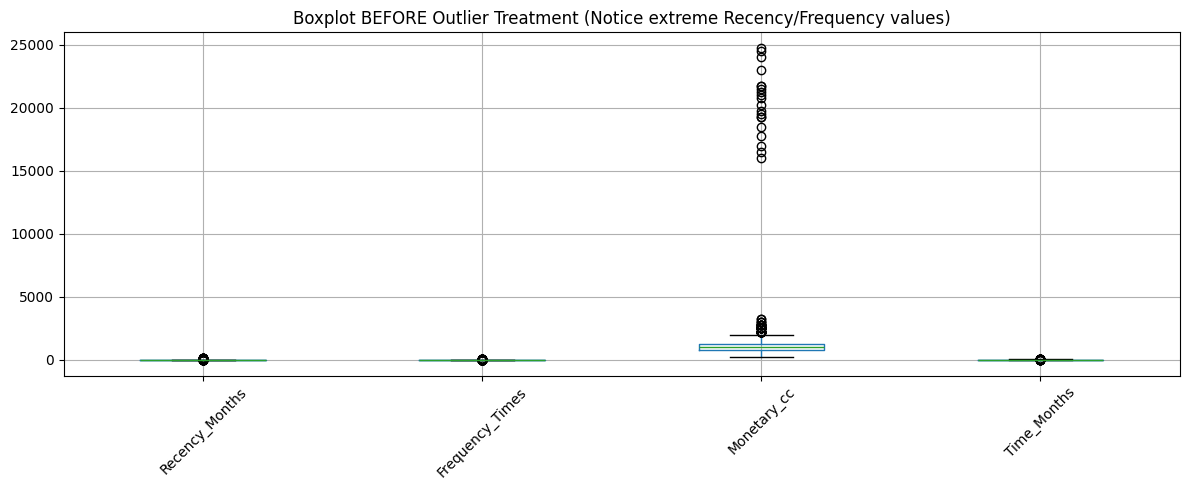

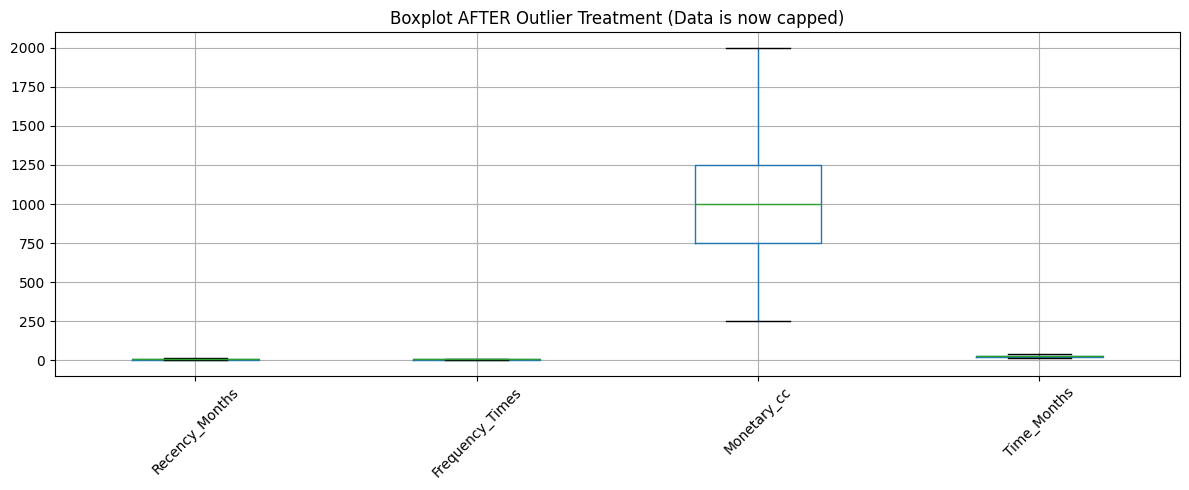

In [4]:
num_cols = [c for c in df.columns if c != 'Eligible_Target']

# Plotting BEFORE Outlier Treatment
plt.figure(figsize=(12, 5))
df[num_cols].boxplot(rot=45)
plt.title('Boxplot BEFORE Outlier Treatment (Notice extreme Recency/Frequency values)')
plt.tight_layout()
plt.show()

# Outlier Treatment using IQR Method
def clip_outliers(dataframe, col):
    Q1 = dataframe[col].quantile(0.25)
    Q3 = dataframe[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    dataframe[col] = np.clip(dataframe[col], lower_bound, upper_bound)
    return dataframe

for col in num_cols:
    df = clip_outliers(df, col)

# Plotting AFTER Outlier Treatment
plt.figure(figsize=(12, 5))
df[num_cols].boxplot(rot=45)
plt.title('Boxplot AFTER Outlier Treatment (Data is now capped)')
plt.tight_layout()
plt.show()

## 4. Exploratory Data Analysis & Correlation

/tmp/ipykernel_4754/1692856095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Eligible_Target', data=df, palette='Set2')


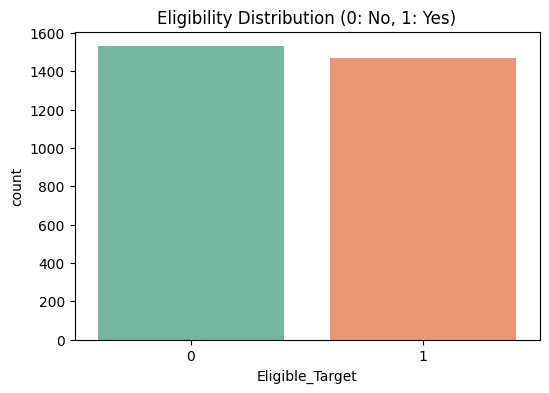

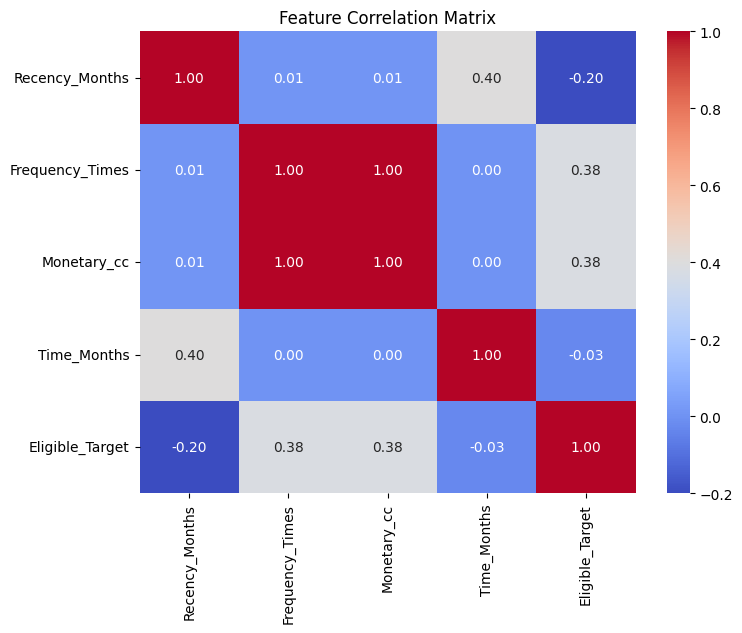

In [5]:
# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Eligible_Target', data=df, palette='Set2')
plt.title('Eligibility Distribution (0: No, 1: Yes)')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

## 5. Feature Scaling & Data Splitting

In [6]:
X = df.drop(columns=['Eligible_Target'])
y = df['Eligible_Target']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression requires scaled features for optimal performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train size: {X_train.shape}')
print(f'Test size : {X_test.shape}')

Train size: (2400, 4)
Test size : (600, 4)


## 6. Model Training (Logistic Regression)

In [7]:
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, Y_train)

LogisticRegression(class_weight='balanced', random_state=42)

## 7. Model Evaluation

Accuracy Score: 67.50%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.70      0.69       306
           1       0.68      0.65      0.66       294

    accuracy                           0.68       600
   macro avg       0.68      0.67      0.67       600
weighted avg       0.68      0.68      0.67       600



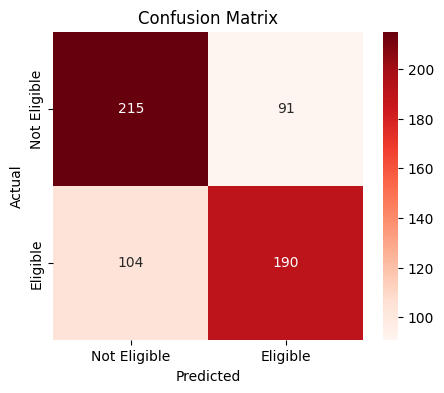

In [8]:
Y_pred = model.predict(X_test_scaled)
acc = accuracy_score(Y_test, Y_pred)

print(f'Accuracy Score: {acc*100:.2f}%\n')
print("Classification Report:")
print(classification_report(Y_test, Y_pred))

# Confusion Matrix
matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Eligible', 'Eligible'],
            yticklabels=['Not Eligible', 'Eligible'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()